# Hafta 3 — ADD'ler için Sayısal Yöntemler

> **Bilim İnsanları ve Mühendisler için Diferansiyel Denklemler**  
> *Euler, Runge-Kutta, Adams-Bashforth — her çözücü ilk ilkelerden kurulur.*

---

## Öğrenme Hedefleri

1. Euler yöntemi için **Taylor serisi hata analizini** türetmek (YKH ve KKH)
2. **Orta nokta**, **Heun** ve **klasik RK4**'ü sıfırdan uygulamak
3. **Çok adımlı yöntemler** kurmak: Adams-Bashforth (açık) ve Adams-Moulton (kapalı)
4. Teorik hata oranlarını deneysel olarak doğrulamak için **mertebe-yakınsama grafikleri** üretmek
5. Çözücüleri Lorenz sistemi ve van der Pol salınıcısı üzerinde karşılaştırmak


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
})

---

## 1. Euler Yöntemi — Türetme ve Hata Analizi

$y' = f(t, y)$, $y(t_0) = y_0$ düşünün. $y(t+h)$'yi Taylor serisine açın:

$$y(t+h) = y(t) + h\,y'(t) + \frac{h^2}{2}y''(t) + O(h^3)$$

Birinci mertebeden terimden sonra kesmek **Euler yöntemini** verir:

$$\boxed{y_{n+1} = y_n + h\,f(t_n, y_n)}$$

- **Yerel Kesme Hatası (YKH):** $\tau_n = O(h^2)$ — adım başına hata
- **Küresel Kesme Hatası (KKH):** $e_n = O(h)$ — sabit $T$'de hata (birinci mertebeden yöntem)

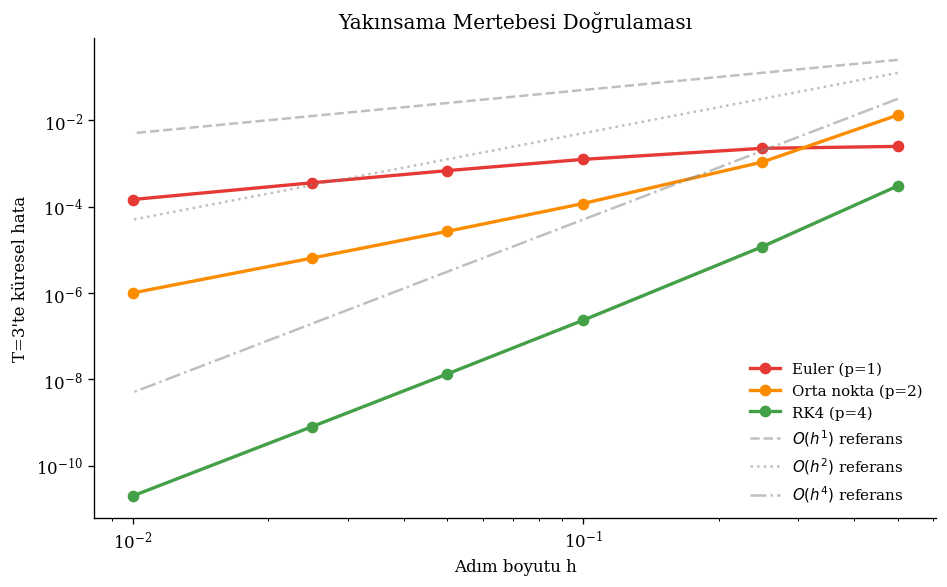

In [2]:
def euler(f, t0, y0, T, h):
    """y' = f(t, y) için ileri Euler çözücüsü. (t_dizi, y_dizi) döndürür."""
    t_dizi = np.arange(t0, T + h/2, h)
    y_dizi = np.zeros((len(t_dizi), *np.shape(y0)))
    y_dizi[0] = y0
    for n in range(len(t_dizi) - 1):
        y_dizi[n+1] = y_dizi[n] + h * np.asarray(f(t_dizi[n], y_dizi[n]))
    return t_dizi, y_dizi


def orta_nokta(f, t0, y0, T, h):
    """Açık orta nokta (RK2) çözücüsü."""
    t_dizi = np.arange(t0, T + h/2, h)
    y_dizi = np.zeros((len(t_dizi), *np.shape(y0)))
    y_dizi[0] = y0
    for n in range(len(t_dizi) - 1):
        yn = y_dizi[n]; tn = t_dizi[n]
        k1 = np.asarray(f(tn, yn))
        k2 = np.asarray(f(tn + h/2, yn + h/2 * k1))
        y_dizi[n+1] = yn + h * k2
    return t_dizi, y_dizi


def rk4(f, t0, y0, T, h):
    """Klasik 4. mertebeden Runge-Kutta çözücüsü."""
    t_dizi = np.arange(t0, T + h/2, h)
    y_dizi = np.zeros((len(t_dizi), *np.shape(y0)))
    y_dizi[0] = y0
    for n in range(len(t_dizi) - 1):
        yn = y_dizi[n]; tn = t_dizi[n]
        k1 = np.asarray(f(tn,        yn))
        k2 = np.asarray(f(tn + h/2,  yn + h/2 * k1))
        k3 = np.asarray(f(tn + h/2,  yn + h/2 * k2))
        k4 = np.asarray(f(tn + h,    yn + h   * k3))
        y_dizi[n+1] = yn + h/6 * (k1 + 2*k2 + 2*k3 + k4)
    return t_dizi, y_dizi


# ---- y' = -2y, y(0)=1, y_tam = e^(-2t) üzerinde yakınsama testi ----
f_test    = lambda t, y: np.array([-2.0 * y[0]])
y_tam     = lambda T: np.exp(-2.0 * T)
T_son      = 3.0
h_degerleri  = np.array([0.5, 0.25, 0.1, 0.05, 0.025, 0.01])

yontemler = {
    'Euler (p=1)':        (euler,      1, '#E53935'),
    'Orta nokta (p=2)':   (orta_nokta, 2, '#FB8C00'),
    'RK4 (p=4)':          (rk4,        4, '#43A047'),
}

fig, ax = plt.subplots(figsize=(8, 5))
for etiket, (cozucu, mertebe, renk) in yontemler.items():
    hatalar = []
    for h in h_degerleri:
        _, y_dizi = cozucu(f_test, 0.0, np.array([1.0]), T_son, h)
        hatalar.append(abs(y_dizi[-1, 0] - y_tam(T_son)))
    ax.loglog(h_degerleri, hatalar, 'o-', color=renk, lw=2, label=etiket)

# Referans eğimleri
h_ref = np.array([h_degerleri[0], h_degerleri[-1]])
for mertebe, ls, alpha in [(1, '--', 0.5), (2, ':', 0.5), (4, '-.', 0.5)]:
    ax.loglog(h_ref, 0.5 * h_ref**mertebe, ls=ls, color='gray', alpha=alpha,
              label=f'$O(h^{mertebe})$ referans')

ax.set_xlabel('Adım boyutu h'); ax.set_ylabel('T=3\'te küresel hata')
ax.set_title('Yakınsama Mertebesi Doğrulaması')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

---

## 2. Runge-Kutta Ailesi — RK2'den RK4'e

**Runge-Kutta** yöntemleri (çok adımlının aksine) geçmişi saklamaktan kaçınır; her adımda $f$'yi birden fazla **aşamada** değerlendirir.

**RK2 (Orta nokta yöntemi):** İki aşama, 2. mertebe doğruluk ($O(h^2)$):
$$k_1 = f(t_n, y_n), \quad k_2 = f\!\left(t_n + \tfrac{h}{2},\, y_n + \tfrac{h}{2}k_1\right)$$
$$y_{n+1} = y_n + h\,k_2$$

**RK4 (Klasik):** Dört aşama, 4. mertebe doğruluk ($O(h^4)$):
$$k_1 = f(t_n,y_n),\quad k_2 = f(t_n+\tfrac{h}{2}, y_n+\tfrac{h}{2}k_1)$$
$$k_3 = f(t_n+\tfrac{h}{2}, y_n+\tfrac{h}{2}k_2),\quad k_4 = f(t_n+h, y_n+hk_3)$$
$$y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

**Butcher tablosu**, herhangi bir RK şeması için kompakt bir gösterimdir:
$$\begin{array}{c|cc}0 & \\ 1/2 & 1/2 & \\ \hline & 0 & 1\end{array}\quad\text{(RK2 Orta nokta)}$$

**Yakınsama:** küresel hata $E \propto h^p$, burada $p$ mertebedir — $h$'yi ikiye katlayıp $E$'yi ölçerek deneysel olarak doğrulanır.

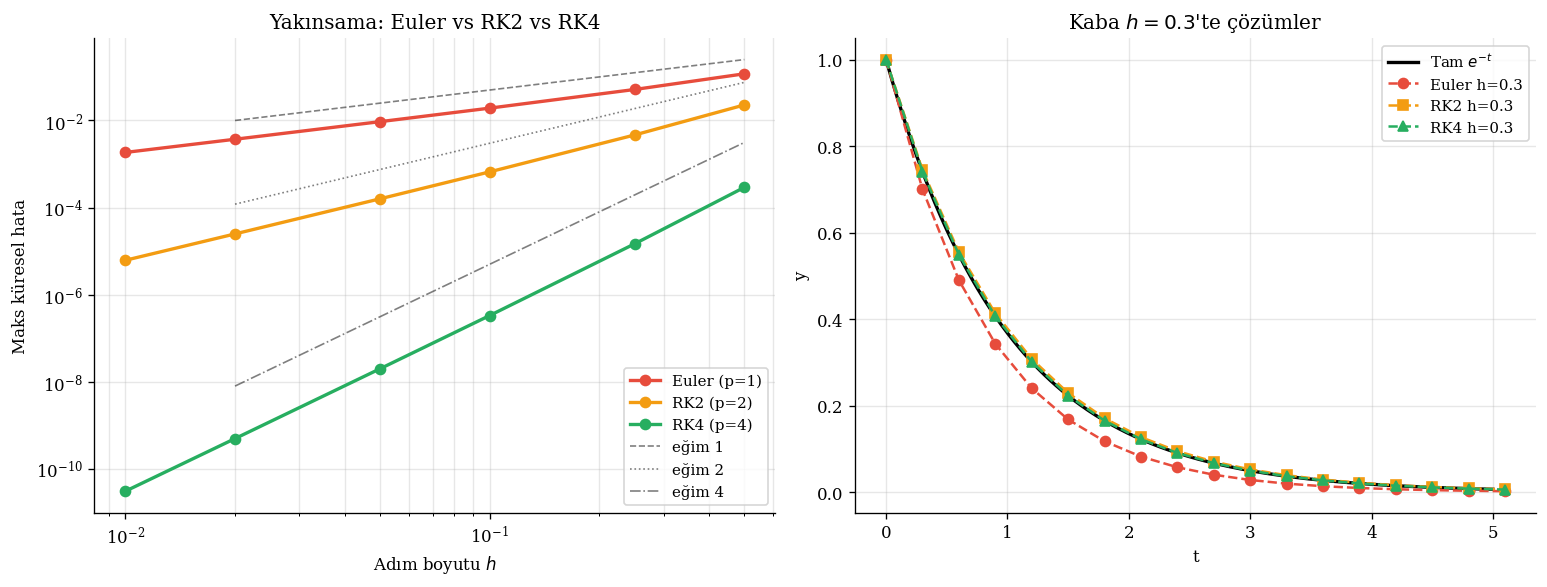

In [3]:
def rk2_orta_nokta(f, t0, y0, T, h):
    """Açık orta nokta (RK2) yöntemi: 2. mertebeden Runge-Kutta."""
    t_dizi = np.arange(t0, T + h/2, h)
    y_dizi = np.zeros((len(t_dizi), *np.shape(y0)))
    y_dizi[0] = y0
    for n in range(len(t_dizi) - 1):
        k1 = np.asarray(f(t_dizi[n], y_dizi[n]))
        k2 = np.asarray(f(t_dizi[n] + h/2, y_dizi[n] + h/2 * k1))
        y_dizi[n+1] = y_dizi[n] + h * k2
    return t_dizi, y_dizi


# ── y' = -y, tam: y = e^{-t} üzerinde yakınsama testi ─────────────────────────
def f_test2(t, y): return -y
y0_test, T_test = np.array([1.0]), 5.0
y_tam_fonk = lambda t: np.exp(-t)

h_degerleri = [0.5, 0.25, 0.1, 0.05, 0.02, 0.01]
yontemler2 = {
    'Euler (p=1)':        (euler,           '#e74c3c'),
    'RK2 (p=2)':          (rk2_orta_nokta,  '#f39c12'),
    'RK4 (p=4)':          (rk4,             '#27ae60'),
}

fig, eksenler = plt.subplots(1, 2, figsize=(13, 5))
ax_yak = eksenler[0]

for etiket, (yontem, renk) in yontemler2.items():
    hatalar = []
    for h in h_degerleri:
        t_dizi, y_dizi = yontem(f_test2, 0, y0_test, T_test, h)
        hata = np.max(np.abs(y_dizi[:,0] - y_tam_fonk(t_dizi)))
        hatalar.append(hata)
    ax_yak.loglog(h_degerleri, hatalar, 'o-', color=renk, lw=2, label=etiket)

# Referans eğimleri
h_ref = np.array([0.02, 0.5])
ax_yak.loglog(h_ref, 0.5*h_ref**1, 'k--', lw=1, alpha=0.5, label='eğim 1')
ax_yak.loglog(h_ref, 0.3*h_ref**2, 'k:',  lw=1, alpha=0.5, label='eğim 2')
ax_yak.loglog(h_ref, 0.05*h_ref**4,'k-.', lw=1, alpha=0.5, label='eğim 4')
ax_yak.set_xlabel('Adım boyutu $h$'); ax_yak.set_ylabel('Maks küresel hata')
ax_yak.set_title('Yakınsama: Euler vs RK2 vs RK4')
ax_yak.legend(fontsize=9); ax_yak.grid(alpha=0.3, which='both')

# Kaba adımda yan yana çözümler
ax_coz = eksenler[1]
h_kaba = 0.3
t_e, y_e   = euler(f_test2, 0, np.array([1.0]), 5.0, h_kaba)
t_r2, y_r2 = rk2_orta_nokta(f_test2, 0, np.array([1.0]), 5.0, h_kaba)
t_r4, y_r4 = rk4(f_test2, 0, np.array([1.0]), 5.0, h_kaba)
t_ince = np.linspace(0, 5, 400)
ax_coz.plot(t_ince, np.exp(-t_ince), 'k-', lw=2, label='Tam $e^{-t}$')
ax_coz.plot(t_e,  y_e[:,0],  'o--', color='#e74c3c', label=f'Euler h={h_kaba}')
ax_coz.plot(t_r2, y_r2[:,0], 's--', color='#f39c12', label=f'RK2 h={h_kaba}')
ax_coz.plot(t_r4, y_r4[:,0], '^--', color='#27ae60', label=f'RK4 h={h_kaba}')
ax_coz.set_xlabel('t'); ax_coz.set_ylabel('y')
ax_coz.set_title(f"Kaba $h={h_kaba}$\'te çözümler")
ax_coz.legend(fontsize=9); ax_coz.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## 3. Çok Adımlı Yöntemler — Adams Ailesi

Tek adımlı yöntemler her adımda tüm fonksiyon değerlerini yeniden hesaplar.  
**Çok adımlı** yöntemler geçmiş değerlendirmeleri geri dönüştürür:

**Adams-Bashforth 4 adımlı (açık, mertebe 4):**

$$y_{n+1} = y_n + \frac{h}{24}\bigl(55f_n - 59f_{n-1} + 37f_{n-2} - 9f_{n-3}\bigr)$$

**Adams-Moulton 3 adımlı (kapalı, mertebe 4):**

$$y_{n+1} = y_n + \frac{h}{24}\bigl(9f_{n+1} + 19f_n - 5f_{n-1} + f_{n-2}\bigr)$$

Bir **kestirici-düzeltici** çifti (AB4-AM4), aynı mertebede RK4 için dört yerine adım başına $f$'yi iki kez değerlendirir.

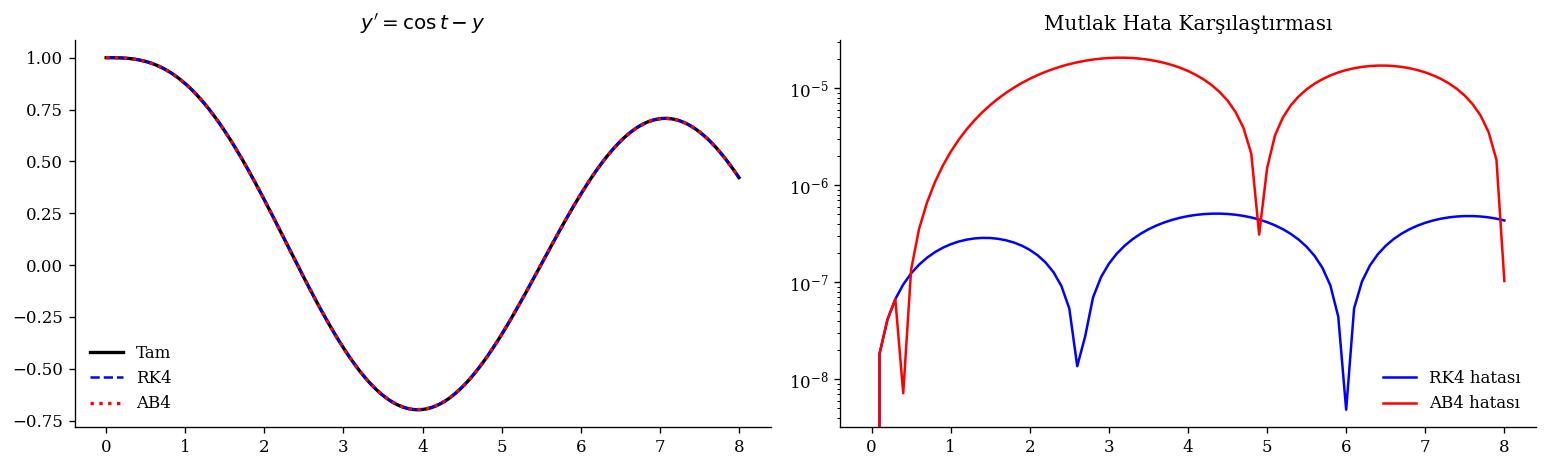

In [4]:
def adams_bashforth4(f, t0, y0, T, h):
    """4 adımlı Adams-Bashforth. İlk 3 adımı üretmek için RK4 kullanır."""
    # RK4 ile başlatma
    t_dizi = [t0]
    y_dizi = [np.asarray(y0, dtype=float)]
    f_dizi = [np.asarray(f(t0, y_dizi[0]))]

    for _ in range(3):
        yn = y_dizi[-1]; tn = t_dizi[-1]
        k1 = np.asarray(f(tn,        yn))
        k2 = np.asarray(f(tn + h/2,  yn + h/2*k1))
        k3 = np.asarray(f(tn + h/2,  yn + h/2*k2))
        k4 = np.asarray(f(tn + h,    yn + h*k3))
        y_sonraki = yn + h/6*(k1 + 2*k2 + 2*k3 + k4)
        t_sonraki = tn + h
        t_dizi.append(t_sonraki); y_dizi.append(y_sonraki)
        f_dizi.append(np.asarray(f(t_sonraki, y_sonraki)))

    # AB4 ana döngü
    while t_dizi[-1] < T - h/2:
        fn   = f_dizi[-1]; fn1 = f_dizi[-2]; fn2 = f_dizi[-3]; fn3 = f_dizi[-4]
        y_sonraki = y_dizi[-1] + h/24 * (55*fn - 59*fn1 + 37*fn2 - 9*fn3)
        t_sonraki = t_dizi[-1] + h
        t_dizi.append(t_sonraki); y_dizi.append(y_sonraki)
        f_dizi.append(np.asarray(f(t_sonraki, y_sonraki)))

    return np.array(t_dizi), np.array(y_dizi)


# AB4'ü RK4 ile y' = cos(t) - y üzerinde karşılaştır, tam: y = 0.5*(cos t + sin t + e^{-t})
f_cos = lambda t, y: np.array([np.cos(t) - y[0]])
y_tam_cos = lambda t: 0.5 * (np.cos(t) + np.sin(t) + np.exp(-t))

T = 8.0; h = 0.1
t_rk4, y_rk4 = rk4(f_cos, 0, np.array([1.0]), T, h)
t_ab4,  y_ab4  = adams_bashforth4(f_cos, 0, np.array([1.0]), T, h)
t_tam = np.linspace(0, T, 800)

fig, eksenler = plt.subplots(1, 2, figsize=(13, 4))
eksenler[0].plot(t_tam, y_tam_cos(t_tam), 'k-', lw=2, label='Tam')
eksenler[0].plot(t_rk4, y_rk4[:, 0], 'b--', lw=1.5, label='RK4')
eksenler[0].plot(t_ab4, y_ab4[:, 0], 'r:', lw=2, label='AB4')
eksenler[0].legend(frameon=False); eksenler[0].set_title("$y' = \\cos t - y$")

eksenler[1].semilogy(t_rk4, np.abs(y_rk4[:, 0] - y_tam_cos(t_rk4)), 'b-', label='RK4 hatası')
eksenler[1].semilogy(t_ab4, np.abs(y_ab4[:, 0] - y_tam_cos(t_ab4)), 'r-', label='AB4 hatası')
eksenler[1].legend(frameon=False); eksenler[1].set_title('Mutlak Hata Karşılaştırması')

plt.tight_layout(); plt.show()

---

## 4. Uygulama — Lorenz Sistemi

Lorenz sistemi, **deterministik kaosun** kanonik örneğidir:

$$\dot{x} = \sigma(y - x), \quad \dot{y} = x(\rho - z) - y, \quad \dot{z} = xy - \beta z$$

Klasik parametreler: $\sigma = 10$, $\rho = 28$, $\beta = 8/3$.

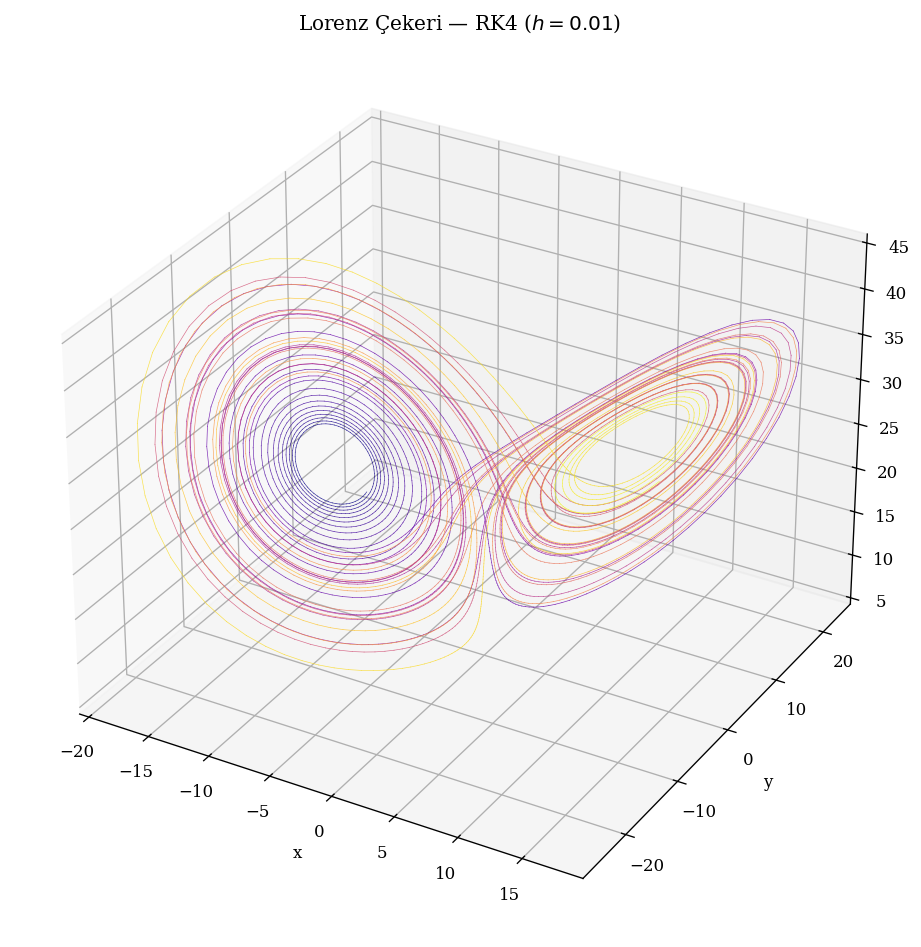

In [5]:
def lorenz(t, durum, sigma=10., rho=28., beta=8./3.):
    x, y, z = durum
    return np.array([
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ])

_, xyz = rk4(lorenz, 0, np.array([1., 1., 1.]), 50, 0.01)
atla = 500  # geçici rejimi at

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

N = len(xyz[atla:])
renkler = cm.plasma(np.linspace(0, 1, N))
for i in range(N - 1):
    ax.plot(xyz[atla+i:atla+i+2, 0],
            xyz[atla+i:atla+i+2, 1],
            xyz[atla+i:atla+i+2, 2],
            color=renkler[i], lw=0.4, alpha=0.8)

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Lorenz Çekeri — RK4 ($h=0.01$)')
plt.tight_layout(); plt.show()

---

## 5. Alıştırmalar

1. **(Euler hatası)** $y' = \lambda y$, $y(0)=1$ için, $T=1$'deki küresel hatayı $h$ ve $\lambda$'nın fonksiyonu olarak analitik türetin. Formülünüzü $\lambda = -1, -5, -20$ için sayısal doğrulayın.

2. **(Heun yöntemi)** Heun yöntemini (yamuk kestirici-düzeltici, mertebe 2) uygulayın ve yakınsama grafiğine ekleyin. Eğimini doğrulayın.

3. **(Butcher tablosu)** Genel Butcher-tablosu çözücüsünü kullanarak **3/8-kuralı RK4**'ü uygulayın ve klasik RK4 ile aynı mertebeyi verdiğini doğrulayın.

4. **(Adams-Moulton)** AB4-AM4 kestirici-düzeltici çiftini uygulayın. Lorenz sistemi üzerinde doğruluğunu ve maliyetini (fonksiyon değerlendirmeleri) RK4 ile karşılaştırın.

5. **(Kaos)** Bir bileşeninde $10^{-8}$ kadar farklı başlangıç koşullarıyla iki Lorenz yörüngesi çalıştırın. Aralarındaki mesafeyi zamana göre çizin ve **Lyapunov üstelini** tahmin edin.
